# **EDA**

In [67]:
#Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [68]:
#Loading the cleaned dataset from Github
url = 'https://raw.githubusercontent.com/rameshramz-dev/ttc-data-analysis/refs/heads/main/TTC_Subway_Delay_Cleaned_2022_June2026.csv'
df = pd.read_csv(url)
df.drop(columns=['Unnamed: 0'], inplace=True)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Month_Name'] = df['Datetime'].dt.month_name()
print(df.shape)
#print(df.info())
#print(df.columns)
print(df['Year'].value_counts().sort_index())
df.head(5)

(106930, 22)
Year
2022    18576
2023    22012
2024    26167
2025    25430
2026    14745
Name: count, dtype: int64


,Date,Time,Day,Station,Code,Min Delay,Min Gap,Line,Vehicle,Code_Description,...,Year,Month,Day_Num,Hour,Weekday,DayName,Peak_Hour,Weekend,Season,Month_Name
0,2022-01-01 00:00:00,02:23,Saturday,SPADINA BD STATION,MUIS,0,0,BD,0,Injured or ill Customer (In Station) - Transpo...,...,2022,1,1,2,5,Saturday,0,1,Winter,January
1,2022-01-01 00:00:00,02:28,Saturday,VAUGHAN MC STATION,MUIS,0,0,YU,0,Injured or ill Customer (In Station) - Transpo...,...,2022,1,1,2,5,Saturday,0,1,Winter,January
2,2022-01-01 00:00:00,02:34,Saturday,EGLINTON STATION,MUATC,0,0,YU,5981,ATC Project,...,2022,1,1,2,5,Saturday,0,1,Winter,January
3,2022-01-01 00:00:00,05:40,Saturday,QUEEN STATION,MUNOA,0,0,YU,0,No Operator Immediately Available - Not E.S.A....,...,2022,1,1,5,5,Saturday,0,1,Winter,January
4,2022-01-01 00:00:00,06:56,Saturday,DAVISVILLE STATION,MUNOA,0,0,YU,0,No Operator Immediately Available - Not E.S.A....,...,2022,1,1,6,5,Saturday,0,1,Winter,January


# Total Delay and Distribution by Month

In [69]:
#Choosing the year for Analysis
while True:
  yr = input("Enter Year for analysis :")
  if yr == 'All':
    yr_df = df
    yr_al = yr_df.groupby('Year')['Min Delay'].agg(['count','sum','max'])
    print(yr_al.sort_values(by='sum',ascending=False))
    break
  elif int(yr) in df['Year'].unique():
    yr_df = df[df['Year'] == int(yr)]
    break
  else:
    print("Invalid Year")

df_nn=yr_df[yr_df['Min Delay']!= 0]
#yr_df = df[(df['Year'] == yr) & (df['Min Delay'] != 0)]
yr_delays = yr_df['Min Delay'].count()
sm_delays = yr_df['Min Delay'].sum()/(60)
print(f"Total delay incidents in {yr}: {yr_delays}")
print(f"Total delay time in {yr}: {sm_delays:.2f} hours, translates to {sm_delays/24:.2f} days")
#total dealys by season
season = yr_df.groupby('Season')['Min Delay'].count()
season_nn = df_nn.groupby('Season')['Min Delay'].count()
print(season.sort_values(ascending=False))
#total dealys by month
mo_wise = yr_df.groupby('Month_Name')['Min Delay'].count()
mo_wise_nn = df_nn.groupby('Month_Name')['Min Delay'].count()
print(mo_wise.sort_values(ascending=False))

Enter Year for analysis :2025
Total delay incidents in 2025: 25430
Total delay time in 2025: 1176.78 hours, translates to 49.03 days
Season
Summer    6717
Winter    6541
Spring    6207
Fall      5965
Name: Min Delay, dtype: int64
Month_Name
August       2693
February     2243
December     2210
November     2174
May          2151
July         2110
January      2088
April        2087
October      2007
March        1969
June         1914
September    1784
Name: Min Delay, dtype: int64


In [70]:
#avg delay time
avg_delay = df_nn['Min Delay'].mean()
print(f"Average delay time in {yr}: {avg_delay:.2f} minutes")
#total dealys by season
season_avg = df_nn.groupby('Season')['Min Delay'].mean()
print(season_avg.sort_values(ascending=False))
#avg dealy by month
mo_wise_avg = df_nn.groupby('Month_Name')['Min Delay'].mean()
print(mo_wise_avg.sort_values(ascending=False))

Average delay time in 2025: 7.79 minutes
Season
Winter    8.422491
Spring    7.791557
Summer    7.574641
Fall      7.227252
Name: Min Delay, dtype: float64
Month_Name
February     9.578313
July         8.142649
April        8.069612
January      7.897277
March        7.844806
June         7.713424
December     7.671429
November     7.451028
May          7.447802
October      7.321479
August       6.922973
September    6.817292
Name: Min Delay, dtype: float64


In [71]:
#Month and code with most delays
lc_delays=df_nn.groupby(['Month','Month_Name','Code','Code_Description'])['Min Delay'].agg(['count','sum','mean','max'])

val=lc_delays.sort_values(by='sum',ascending=False).groupby('Month_Name').head(3)
val.sort_values(by=['Month','sum'],ascending=[True, False] )


count  \
Month Month_Name Code  Code_Description                                            
1     January    SUDP  Disorderly Patron                                     159   
                 SUUT  Unauthorized at Track Level                            32   
                 MUIR  Injured or ill Customer (On Train) - Medical Ai...     51   
2     February   MUWEA Weather Reports / Related Delays                      137   
                 SUDP  Disorderly Patron                                     116   
                 SUO   Passenger Other                                        39   
3     March      SUDP  Disorderly Patron                                     102   
                 MUPR1 Priority One - Train in Contact With Person             6   
                 MUI   Injured or ill Customer (On Train) - Transported       39   
4     April      MUI   Injured or ill Customer (On Train) - Transported       32   
                 SUDP  Disorderly Patron                                      83   
                 SUUT  Unauthorized at Track Level                            33   
5     May        SUDP  Disorderly Patron                                      99   
                 MUIR  Injured or ill Customer (On Train) - Medical Ai...     64   
                 PUTWZ Work Zone Problems - Track                             38   
6     June       SUDP  Disorderly Patron                                      82   
                 SUUT  Unauthorized at Track Level                            22   
                 MUIR  Injured or ill Customer (On Train) - Medical Ai...     41   
7     July       SUDP  Disorderly Patron                                      96   
                 MUIR  Injured or ill Customer (On Train) - Medical Ai...     46   
                 SUO   Passenger Other                                        27   
8     August     SUDP  Disorderly Patron                                      75   
                 MUIR  Injured or ill Customer (On Train) - Medical Ai...     58   
                 MUPAA Passenger Assistance Alarm Activated - No Troub...     90   
9     September  MUIR  Injured or ill Customer (On Train) - Medical Ai...     58   
                 SUDP  Disorderly Patron                                      68   
                 PUOPO OPTO (COMMS) Train Door Monitoring                     48   
10    October    SUO   Passenger Other                                        38   
                 SUDP  Disorderly Patron                                      63   
                 SUUT  Unauthorized at Track Level                            32   
11    November   SUDP  Disorderly Patron                                      94   
                 MUIR  Injured or ill Customer (On Train) - Medical Ai...     75   
                 PUTS  Structure Related Problem                              12   
12    December   SUDP  Disorderly Patron                                     120   
                 MUIR  Injured or ill Customer (On Train) - Medical Ai...     66   
                 MUPLB Fire/Smoke Plan B - Source TTC                          6   

                                                                            sum  \
Month Month_Name Code  Code_Description                                           
1     January    SUDP  Disorderly Patron                                   1093   
                 SUUT  Unauthorized at Track Level                          429   
                 MUIR  Injured or ill Customer (On Train) - Medical Ai...   374   
2     February   MUWEA Weather Reports / Related Delays                    2619   
                 SUDP  Disorderly Patron                                    747   
                 SUO   Passenger Other                                      422   
3     March      SUDP  Disorderly Patron                                    649   
                 MUPR1 Priority One - Train in Contact With Person          529   
                 MUI   Injured or ill Customer (On T

In [72]:
#station with most delays
stn_delays=yr_df.groupby('Station')['Min Delay'].agg(['count','sum','mean','max'])
print(stn_delays.sort_values(by='count',ascending=False).head(10))


                    count   sum      mean  max
Station                                       
BLOOR STATION         915  1691  1.848087   58
KENNEDY BD STATION    866  1851  2.137413  202
FINCH STATION         790  1477  1.869620   88
KIPLING STATION       783  2050  2.618135  120
EGLINTON STATION      659  2822  4.282246  807
WILSON STATION        620  2146  3.461290  119
WARDEN STATION        544  1484  2.727941   68
YONGE BD STATION      512  1284  2.507812   85
DUNDAS STATION        501   860  1.716567   63
UNION STATION         473   883  1.866808   80


In [73]:
#lines with most delays
line_delays=yr_df.groupby(['Line'])['Min Delay'].agg(['count','sum','mean','max'])
#line_delays=yr_df.groupby(['Line','Code'])['Min Delay'].agg(['count','sum','mean','max'])
#line_delays=yr_df.groupby(['Line','Station'])['Min Delay'].agg(['count','sum','mean','max'])
line_delays.sort_values(by='count',ascending=False).head(10)


,count,sum,mean,max
Line,,,,
YU,13012,40200,3.089456,900
BD,10999,27292,2.481316,202
SHP,1065,3115,2.924883,167
YU/BD,352,0,0.000000,0
YU/BD/SHP,2,0,0.000000,0


In [74]:
#Line and station with most delays
ls_delays=df_nn.groupby(['Line','Station','Code','Code_Description'])['Min Delay'].agg(['count','sum','mean','max'])
ls_delays.sort_values(by='sum',ascending=False).head(15)

count  \
Line Station               Code  Code_Description                                            
YU   SHEPPARD WEST STATION MUWEA Weather Reports / Related Delays                        7   
     EGLINTON STATION      MUWEA Weather Reports / Related Delays                        4   
     SHEPPARD TO EGLINTON  PUTS  Structure Related Problem                               1   
     YORKDALE STATION      PUTTP Traction Power Rail Related                             1   
     KING STATION          PUTR  Rail Related Problem                                   43   
     LAWRENCE STATION      PUOPO OPTO (COMMS) Train Door Monitoring                     43   
     YORKDALE STATION      PUOPO OPTO (COMMS) Train Door Monitoring                     37   
     EGLINTON STATION      PUTWZ Work Zone Problems - Track                             22   
     BLOOR STATION         SUDP  Disorderly Patron                                      62   
     ROSEDALE STATION      MUWEA Weather Reports / Related Delays                        3   
SHP  DON MILLS STATION     PUSSW Track Switch Failure - Signal Related Problem           4   
YU   EGLINTON STATION      SUDP  Disorderly Patron                                      39   
     SUMMERHILL STATION    MUIR  Injured or ill Customer (On Train) - Medical Ai...     24   
     SHEPPARD WEST STATION SUDP  Disorderly Patron                                      22   
     LAWRENCE STATION      SUUT  Unauthorized at Track Level                             6   

                                                                                     sum  \
Line Station               Code  Code_Description                                          
YU   SHEPPARD WEST STATION MUWEA Weather Reports / Related Delays                    970   
     EGLINTON STATION      MUWEA Weather Reports / Related Delays                    823   
     SHEPPARD TO EGLINTON  PUTS  Structure Related Problem                           480   
     YORKDALE STATION      PUTTP Traction Power Rail Related                         360   
     KING STATION          PUTR  Rail Related Problem                                325   
     LAWRENCE STATION      PUOPO OPTO (COMMS) Train Door Monitoring                  322   
     YORKDALE STATION      PUOPO OPTO (COMMS) Train Door Monitoring                  298   
     EGLINTON STATION      PUTWZ Work Zone Problems - Track                          270   
     BLOOR STATION         SUDP  Disorderly Patron                                   268   
     ROSEDALE STATION      MUWEA Weather Reports / Related Delays                    266   
SHP  DON MILLS STATION     PUSSW Track Switch Failure - Signal Related Problem       265   
YU   EGLINTON STATION      SUDP  Disorderly Patron                                   263   
     SUMMERHILL STATION    MUIR  Injured or ill Customer (On Train) - Medical Ai...  223   
     SHEPPARD WEST STATION SUDP  Disorderly Patron                                   223   
     LAWRENCE STATION      SUUT  Unauthorized at Track Level                         222   

                                                                                           mean  \
Line Station               Code  Code_Description                                                 
YU   SHEPPARD WEST STATION MUWEA Weather Reports / Related Delays                    138.571429   
     EGLINTON STATION      MUWEA Weather Reports / Related Delays                    205.750000   
     SHEPPARD TO EGLINTON  PUTS  Structure Related Problem                           480.000000   
     YORKDALE STATION      PUTTP Traction Power Rail Related                         360.000000   
     KING STATION          PUTR  Rail Related Problem                                  7.558140   
     LAWRENCE STATION      PUOPO OPTO (COMMS) Train Door Monitoring                    7.488372   
     YORKDALE STATION      PUOPO OPTO (COMMS) Train Door Monitoring                    8.054054   
     EGLINTON STATION      PUT

In [75]:
#codes causing delays
code_delays=yr_df.groupby(['Code_Category','Code','Code_Description'])['Min Delay'].agg(['count','sum','mean','max'])
code_delays.sort_values(by='sum',ascending=False).head(10)

count  \
Code_Category               Code  Code_Description                                            
Passenger & Medical         SUDP  Disorderly Patron                                    2944   
                            MUIR  Injured or ill Customer (On Train) - Medical Ai...    841   
Safety & Security           SUUT  Unauthorized at Track Level                           564   
Passenger & Medical         MUI   Injured or ill Customer (On Train) - Transported      412   
                            SUO   Passenger Other                                      1659   
Other                       PUOPO OPTO (COMMS) Train Door Monitoring                   1258   
Passenger & Medical         MUPAA Passenger Assistance Alarm Activated - No Troub...   1366   
Environmental & Cleanliness MUWEA Weather Reports / Related Delays                      210   
Infrastructure & Signals    PUTWZ Work Zone Problems - Track                            242   
Operations & Workforce      TUO   Transportation Department - Other                     451   

                                                                                       sum  \
Code_Category               Code  Code_Description                                           
Passenger & Medical         SUDP  Disorderly Patron                                   7646   
                            MUIR  Injured or ill Customer (On Train) - Medical Ai...  4797   
Safety & Security           SUUT  Unauthorized at Track Level                         3917   
Passenger & Medical         MUI   Injured or ill Customer (On Train) - Transported    3785   
                            SUO   Passenger Other                                     3418   
Other                       PUOPO OPTO (COMMS) Train Door Monitoring                  3406   
Passenger & Medical         MUPAA Passenger Assistance Alarm Activated - No Troub...  2952   
Environmental & Cleanliness MUWEA Weather Reports / Related Delays                    2745   
Infrastructure & Signals    PUTWZ Work Zone Problems - Track                          2319   
Operations & Workforce      TUO   Transportation Department - Other                   1955   

                                                                                           mean  \
Code_Category               Code  Code_Description                                                
Passenger & Medical         SUDP  Disorderly Patron                                    2.597147   
                            MUIR  Injured or ill Customer (On Train) - Medical Ai...   5.703924   
Safety & Security           SUUT  Unauthorized at Track Level                          6.945035   
Passenger & Medical         MUI   Injured or ill Customer (On Train) - Transported     9.186893   
                            SUO   Passenger Other                                      2.060277   
Other                       PUOPO OPTO (COMMS) Train Door Monitoring                   2.707472   
Passenger & Medical         MUPAA Passenger Assistance Alarm Activated - No Troub...   2.161054   
Environmental & Cleanliness MUWEA Weather Reports / Related Delays                    13.071429   
Infrastructure & Signals    PUTWZ Work Zone Problems - Track                           9.582645   
Operations & Workforce      TUO   Transportation Department - Other                    4.334812   

                                                                                      max  
Code_Category               Code  Code_Description                                         
Passenger & Medical         SUDP  Disorderly Patron                                   110  
                            MUIR  Injured or ill Customer (On Train) - Medical Ai...   27  
Safety & Security           SUUT  Unauthorized at Track Level                          79  
Passenger & Medical         MUI   Injured or ill Customer (On Train) - Transported     90  
                            SUO   Passenger Other                          

In [76]:
#where did these incidents occur (Track Intrusion)
code_df=df_nn[yr_df['Code'] == 'SUUT']
code_dis=code_df.groupby(['Line','Station'])['Min Delay'].agg(['count','sum','mean','max'])
code_dis.sort_values(by='count',ascending=False).head(10)

/tmp/ipykernel_960/2763617228.py:2: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



count  sum       mean  max
Line Station                                       
BD   WARDEN STATION         15  162  10.800000   24
YU   BLOOR STATION          14  130   9.285714   32
     DUNDAS STATION         13  107   8.230769   16
     QUEEN STATION          10  127  12.700000   29
     ROSEDALE STATION       10  192  19.200000   30
BD   YONGE BD STATION        8  100  12.500000   26
YU   DAVISVILLE STATION      7   76  10.857143   33
     COLLEGE STATION         7  115  16.428571   28
BD   BAY STATION             7   59   8.428571   16
YU   YORK MILLS STATION      7  173  24.714286   61

In [77]:
#when do these incidents occur (Disorderly Patron)
code_df=yr_df[yr_df['Code'] == 'SUDP']
#code_dis=code_df.groupby(['Peak_Hour','Hour'])['Min Delay'].agg(['count','sum','mean','max'])
code_dis=code_df.groupby(['Station','Hour'])['Min Delay'].agg(['count','sum','mean','max'])
code_dis.sort_values(by='sum',ascending=False).head(10)

,,count,sum,mean,max
Station,Hour,,,,
SHEPPARD WEST STATION,1,14,139,9.928571,23
YORKDALE STATION,12,1,110,110.000000,110
KENNEDY BD STATION,21,6,64,10.666667,50
OSSINGTON STATION,18,4,42,10.500000,27
ROSEDALE STATION,20,3,41,13.666667,28
CHRISTIE STATION,16,4,41,10.250000,20
NORTH YORK CTR STATION,18,1,40,40.000000,40
CASTLE FRANK STATION,15,7,39,5.571429,15
SHEPPARD-YONGE STATION,2,9,37,4.111111,37


In [78]:
#Null value analysis
df_null=yr_df[yr_df['Min Delay'] == 0]
#null_info = df_null.groupby(['Code'])['Min Delay'].count()
null_info = df_null.groupby(['Code_Category','Code','Code_Description'])['Min Delay'].count()
null_info.sort_values(ascending=False).head(10)

Code_Category                Code   Code_Description                                          
Passenger & Medical          MUIS   Injured or ill Customer (In Station) - Transported            2299
                             SUDP   Disorderly Patron                                             1787
                             SUO    Passenger Other                                               1271
                             MUIRS  Injured or ill Customer (In Station) - Medical Aid Refused    1064
Operations & Workforce       TUNOA  No Operator Immediately Available                             1050
                             MUNOA  No Operator Immediately Available - Not E.S.A. Related         940
Infrastructure & Signals     PUMEL  Escalator/Elevator Incident                                    810
Environmental & Cleanliness  MUSC   Miscellaneous Speed Control                                    771
                             MUO    Miscellaneous Other                                            706
Passenger & Medical          MUPAA  Passenger Assistance Alarm Activated - No Trouble Found        656
Name: Min Delay, dtype: int64

In [79]:
#vehicles and codes
vh_df=yr_df[yr_df['Vehicle'] != 0]
filt_df = vh_df[
    vh_df.groupby('Vehicle')['Vehicle'].transform('size') > 60
].reset_index(drop=True)

veh_codes=filt_df.groupby(['Vehicle' ,'Code_Description','Month_Name'])['Min Delay'].agg(['count','sum','mean','max'])
veh=veh_codes.sort_values(by='sum',ascending=False).groupby('Vehicle').head(3)
veh.sort_values(by=['Vehicle','sum'],ascending=[True, False] )

count  \
Vehicle Code_Description                                   Month_Name          
5441    Priority One - Train in Contact With Person        January         1   
        Track Level Debris - Controllable                  November        1   
        OPTO (COMMS) Train Door Monitoring                 June            9   
5541    Track Switch Failure - Signal Related Problem      October         1   
        Disorderly Patron                                  January         5   
        Unauthorized at Track Level                        August          1   
5676    SCADA Related Problems                             October         2   
        Unauthorized at Track Level                        October         1   
        Operator Not In Position                           June            1   
5746    Injured or ill Customer (On Train) - Transported   April           2   
        Unauthorized at Track Level                        January         1   
        Injured or ill Customer (On Train) - Medical Ai... September       2   
5766    Priority One - Train in Contact With Person        August          1   
        Transportation Department - Other                  January         2   
        OPTO (COMMS) Train Door Monitoring                 February        3   
5876    Unauthorized at Track Level                        January         1   
        Disorderly Patron                                  May             2   
        OPTO (COMMS) Train Door Monitoring                 November        8   
5886    Door Problems - Faulty Equipment                   August          1   
        Disorderly Patron                                  December        3   
        Transit Control Related Problems                   April           1   
5896    Unauthorized at Track Level                        May             1   
        Work Zone Problems - Track                         February        1   
        OPTO (COMMS) Train Door Monitoring                 November        8   
6061    Unauthorized at Track Level                        June            1   
                                                           December        2   
        Rail Related Problem                               November        1   
6136    Signals Axle Counter Block Failure                 July            1   
        Assault / Patron Involved                          January         2   
        Door Problems - Faulty Equipment                   February        2   
6156    T&S Other                                          September       1   
        Signal Control Problem - Signals                   September       1   
        Injured or ill Customer (On Train) - Transported   August          1   
6171    Signals - Train Stops                              November        1   
        Traction Power Rail Related                        April           1   
        Transportation Department - Other                  September       1   
6176    Track Switch Failure - Signal Related Problem      June            1   
        Passenger Other                                    October         1   
        Transportation Department - Other                  December        1   
6181    Work Zone Problems - Track                         October         1   
                                                           May             2   
        Speed Control Equipment                            November        5   
6191    Fire/Smoke Plan B - Source TTC                     February        1   
        Disorderly Patron                                  October         1   
        Unauthorized at Track Level                        February        1   

                                                                       sum  \
Vehicle Code_Description                                   Month_Name        
5441    Priority One - Train in Contact With Person        January      90   
        Track Level Debris - Controllable                  November     40  

In [80]:
yr_df[["Min Delay", "Min Gap", "Hour", "Day_Num" ,"Month","Peak_Hour", "Vehicle"]].corr()

,Min Delay,Min Gap,Hour,Day_Num,Month,Peak_Hour,Vehicle
Min Delay,1.000000,0.961676,-0.000388,0.004519,-0.022241,0.009121,0.205239
Min Gap,0.961676,1.000000,0.030178,0.005175,-0.023223,0.013637,0.274645
Hour,-0.000388,0.030178,1.000000,0.018779,0.002497,0.053438,0.003974
Day_Num,0.004519,0.005175,0.018779,1.000000,0.002325,-0.003501,0.007356
Month,-0.022241,-0.023223,0.002497,0.002325,1.000000,-0.010080,0.002220
Peak_Hour,0.009121,0.013637,0.053438,-0.003501,-0.010080,1.000000,0.092776
Vehicle,0.205239,0.274645,0.003974,0.007356,0.002220,0.092776,1.000000


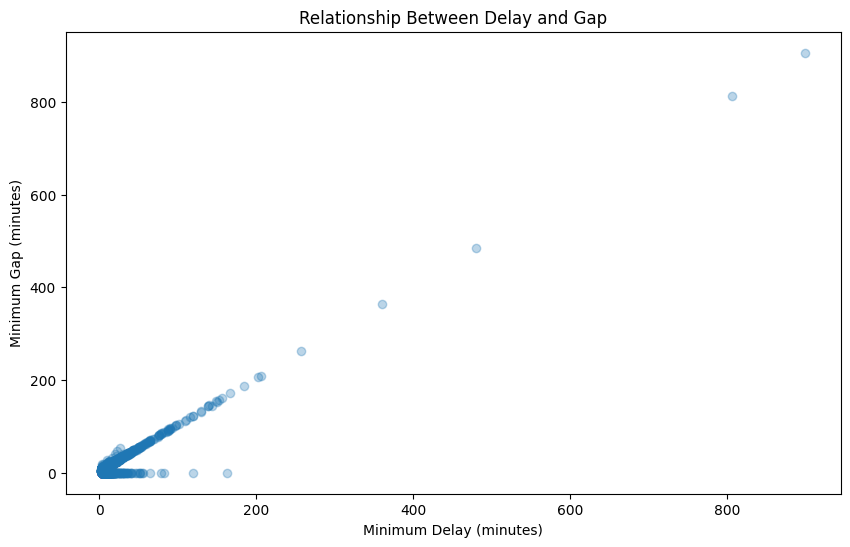

In [81]:
#delay vc gap
plt.figure(figsize=(10, 6))

plt.scatter(
    df_nn["Min Delay"],
    df_nn["Min Gap"],
    alpha=0.3
)

plt.xlabel("Minimum Delay (minutes)")
plt.ylabel("Minimum Gap (minutes)")
plt.title("Relationship Between Delay and Gap")

plt.show()

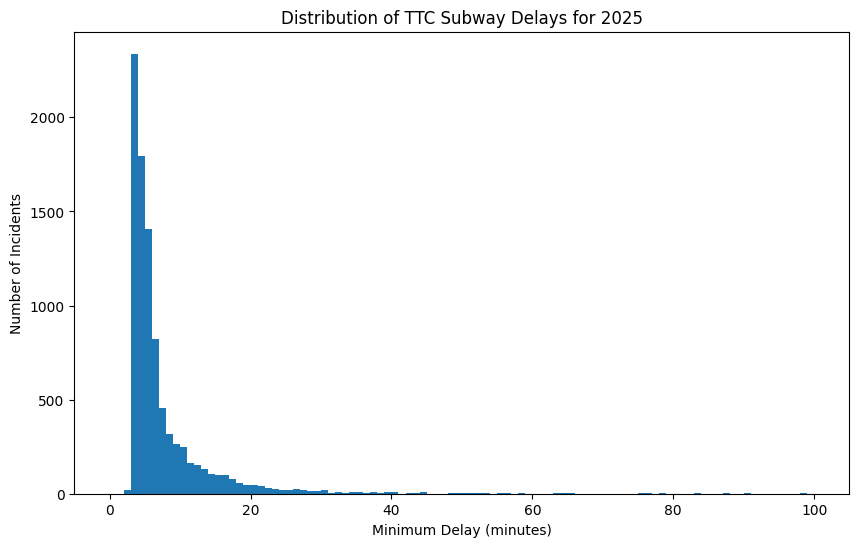

In [82]:
#Distribution
plt.figure(figsize=(10, 6))

plt.hist(df_nn["Min Delay"],range=(0,100) , bins=100)

plt.xlabel("Minimum Delay (minutes)")
plt.ylabel("Number of Incidents")
plt.title(f"Distribution of TTC Subway Delays for {yr}")

plt.show()

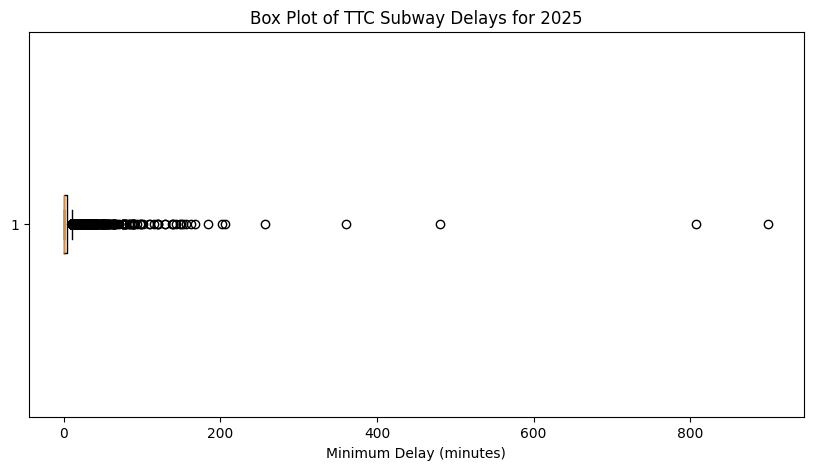

In [83]:
#Boxplot delays
plt.figure(figsize=(10, 5))

plt.boxplot(yr_df["Min Delay"].dropna(), vert=False)

plt.xlabel("Minimum Delay (minutes)")
plt.title(f"Box Plot of TTC Subway Delays for {yr}")

plt.show()


In [84]:
#Outlier Analysis
out_df=yr_df[yr_df['Min Delay']>180]
out_df[['Day','Time','Line','Station','Code_Description','Code_Category','Month_Name','Min Delay']].sort_values(by='Min Delay',ascending=False)

,Day,Time,Line,Station,Code_Description,Code_Category,Month_Name,Min Delay
70037,Sunday,11:03,YU,SHEPPARD WEST STATION,Weather Reports / Related Delays,Environmental & Cleanliness,February,900
70025,Sunday,09:18,YU,EGLINTON STATION,Weather Reports / Related Delays,Environmental & Cleanliness,February,807
89666,Wednesday,18:20,YU,SHEPPARD TO EGLINTON,Structure Related Problem,Infrastructure & Signals,November,480
68139,Wednesday,04:41,YU,YORKDALE STATION,Traction Power Rail Related,Infrastructure & Signals,January,360
70071,Sunday,16:56,YU,ROSEDALE STATION,Weather Reports / Related Delays,Environmental & Cleanliness,February,257
90675,Wednesday,09:32,YU,LAWRENCE STATION,Fire/Smoke Plan B - Source TTC,Safety & Security,December,206
73114,Tuesday,19:42,BD,KENNEDY BD STATION,Traction Power Rail Related,Infrastructure & Signals,April,202
91667,Tuesday,19:09,BD,COXWELL STATION APPROA,Traction Power or Related Components Failure,Infrastructure & Signals,December,184


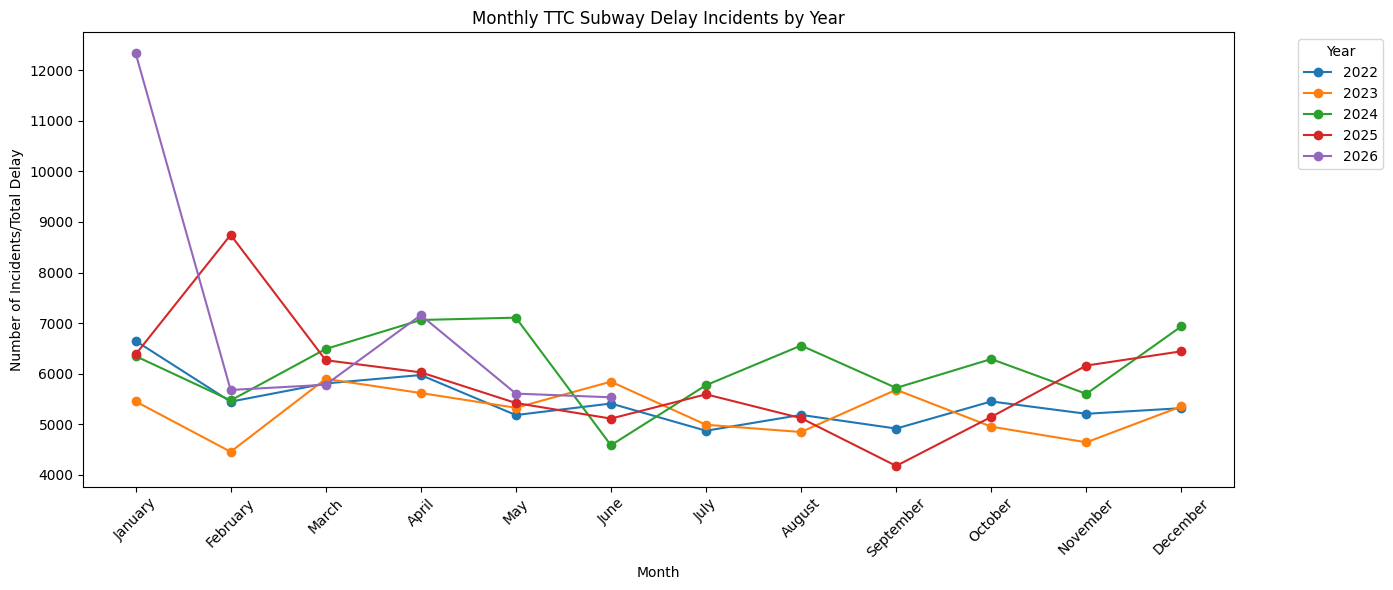

In [99]:
#Distribution of delay events based on Months across the years
dfnn=df[df['Min Delay']!= 0]
monthly_counts = dfnn.groupby(['Month_Name', 'Year'])['Min Delay'].sum().reset_index()
mo_wise_nn = monthly_counts.pivot(index='Month_Name', columns='Year', values='Min Delay')

months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
mo_wise_nn = mo_wise_nn.reindex(months_order)

plt.figure(figsize=(14, 6))
plt.plot(mo_wise_nn.index,mo_wise_nn.values,marker="o")

plt.xlabel("Month")
plt.ylabel("Number of Incidents/Total Delay")
plt.title("Monthly TTC Subway Delay Incidents by Year")
plt.xticks(rotation=45)

plt.legend(mo_wise_nn.columns, title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


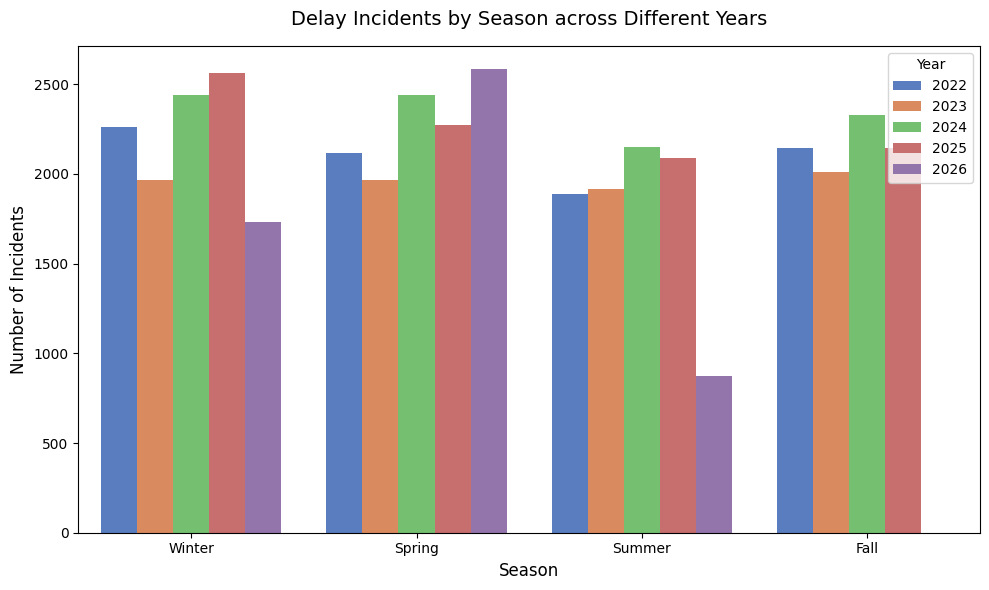

In [86]:
#Based on season across years
df_season = dfnn.groupby(['Year', 'Season']).agg(
    total_incidents=('Min Delay', 'count')
).reset_index()

season_order = ['Winter', 'Spring', 'Summer', 'Fall']

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_season,
    x='Season',
    y='total_incidents',
    hue='Year',
    order=season_order,
    palette='muted'
)

plt.title('Delay Incidents by Season across Different Years', fontsize=14, pad=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.legend(title='Year')

plt.tight_layout()
plt.show()


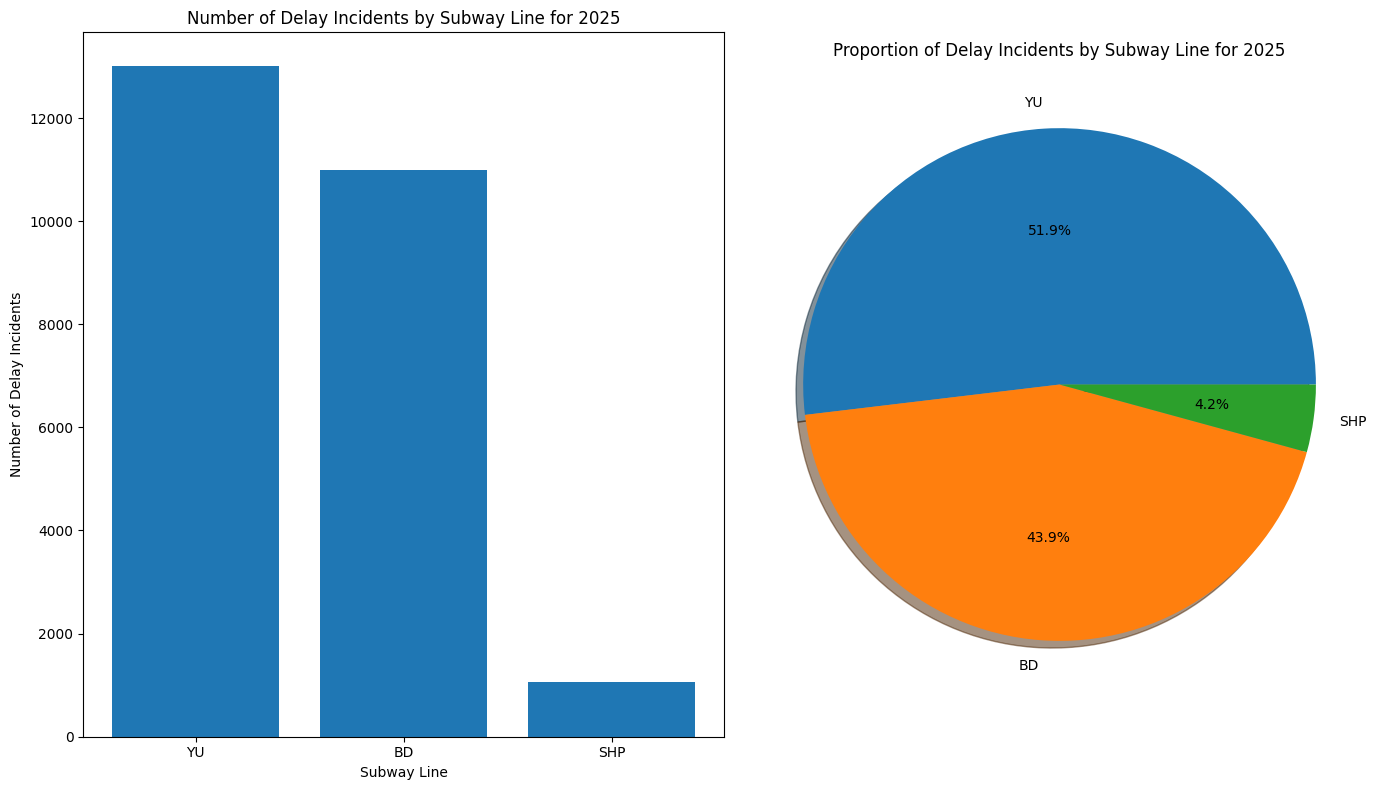

In [87]:
#Delay by line
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 8))

line_counts = yr_df["Line"].value_counts().head(3)

ax1.bar(line_counts.index, line_counts.values)
ax1.set_xlabel("Subway Line")
ax1.set_ylabel("Number of Delay Incidents")
ax1.set_title(f"Number of Delay Incidents by Subway Line for {yr}")

ax2.pie(line_counts.values, labels=line_counts.index, shadow=True , autopct="%1.1f%%")
ax2.set_title(f"Proportion of Delay Incidents by Subway Line for {yr}")

plt.tight_layout()
plt.show()


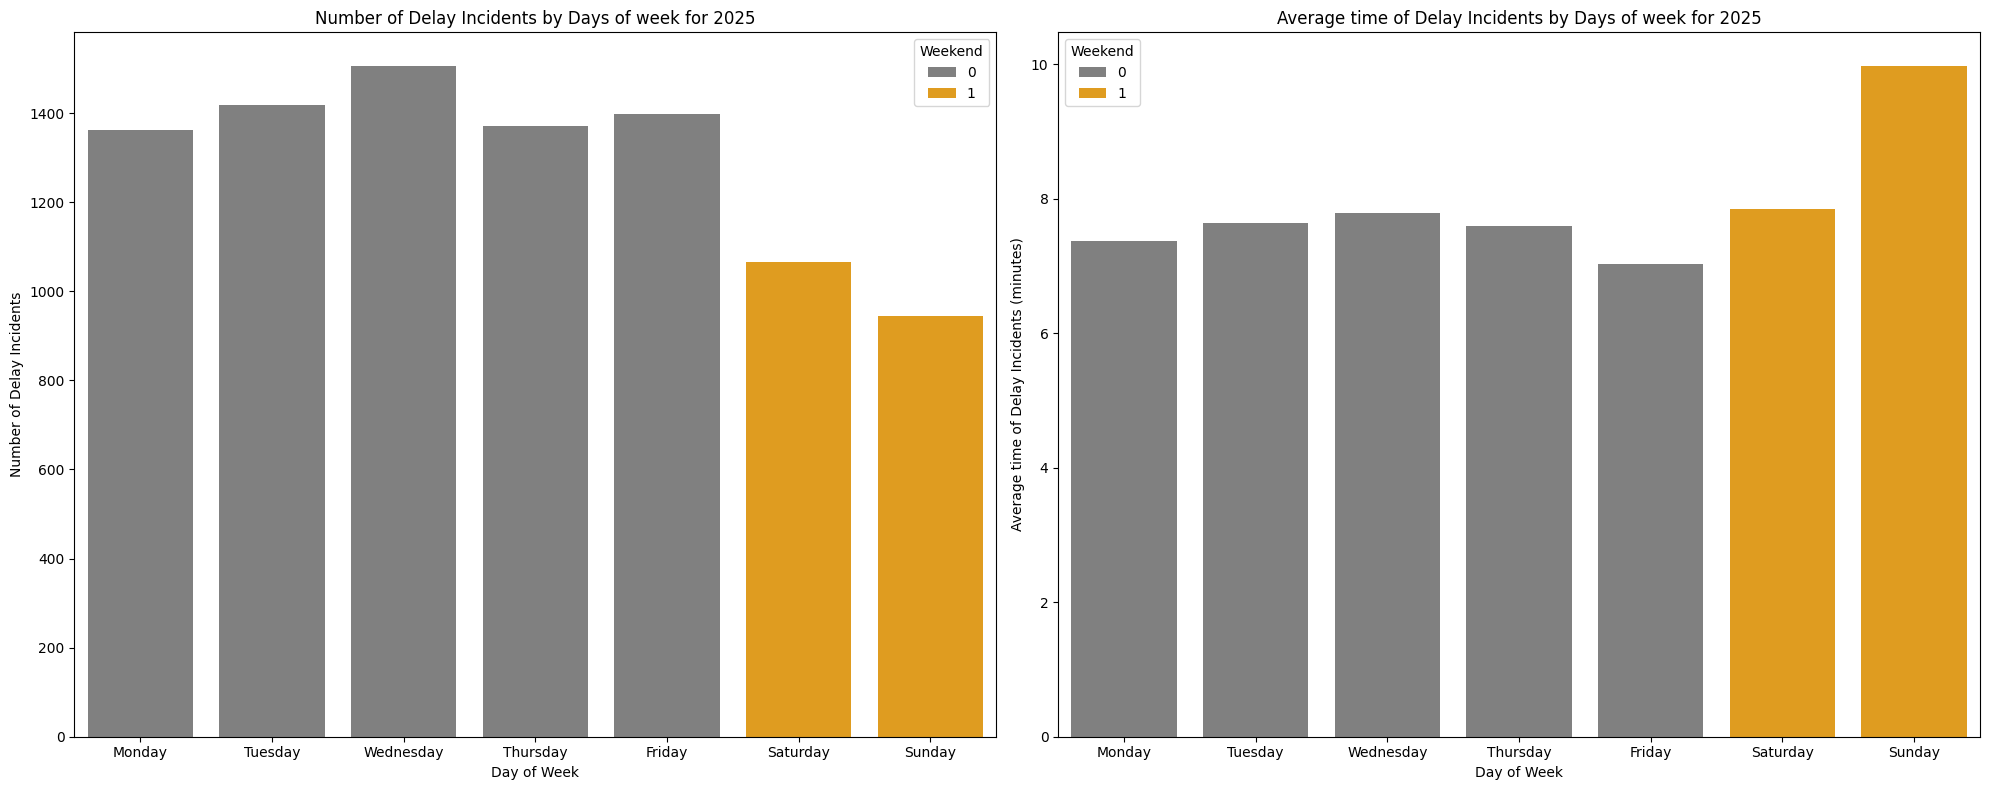

In [100]:
#Distribution based on days of week
counts = df_nn.groupby(['DayName','Weekend']).agg(count=('Min Delay', 'count'),mean=('Min Delay', 'mean'))

days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]
#create subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
custom_palette = {0: "gray", 1: "orange"}

sns.barplot(
    data=counts.reset_index(),
    x='DayName', y='count', hue='Weekend', order=days ,
    palette=custom_palette, ax=ax1
)
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Number of Delay Incidents")
ax1.set_title(f"Number of Delay Incidents by Days of week for {yr}")

sns.barplot(
    data=counts.reset_index(),
    x='DayName', y='mean', hue='Weekend', order=days ,
    palette=custom_palette, ax=ax2
)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Average time of Delay Incidents (minutes)")
ax2.set_title(f"Average time of Delay Incidents by Days of week for {yr}")

plt.tight_layout()
plt.show()

In [89]:
#Pie chart by season
df_pie = df_nn.groupby('Season').agg(count=('Min Delay', 'count')).reset_index()

fig = px.pie(
    df_pie,
    values='count',
    names='Season',
    title=f'Proportion of Delay Incidents by Season for {yr}',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(width=700, height=500)

fig.show()


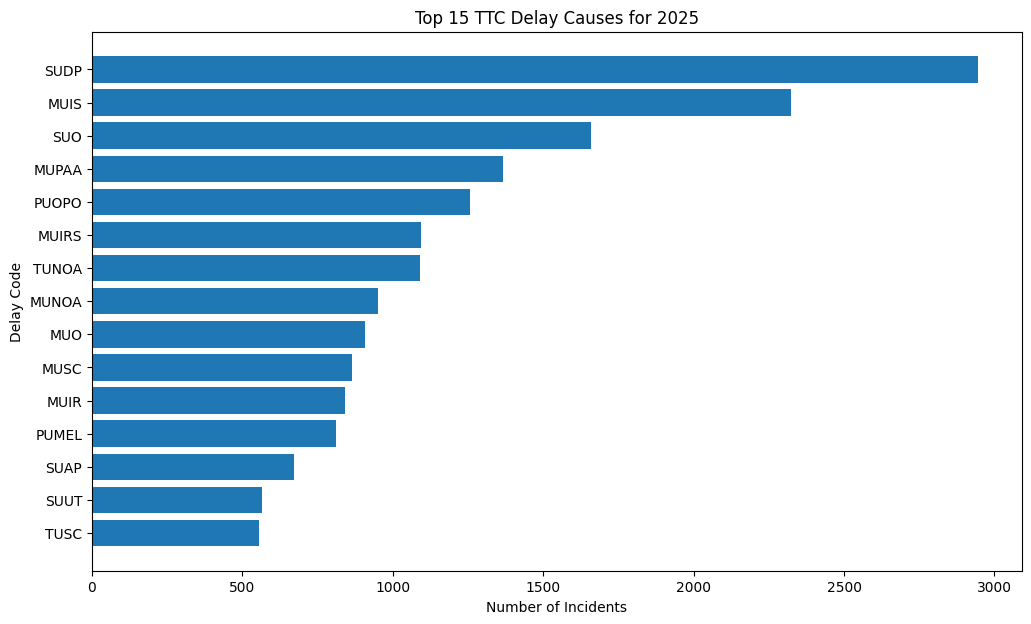

In [90]:
#Top codes causing delays
code_counts = yr_df["Code"].value_counts()
top_codes = code_counts.head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_codes.index[::-1],
    top_codes.values[::-1]
)

plt.xlabel("Number of Incidents")
plt.ylabel("Delay Code")
plt.title(f"Top 15 TTC Delay Causes for {yr}")

plt.show()


In [101]:
#Bubble chart for Delay Code analysis
bubble = df_nn.groupby(['Code', 'Code_Description','Code_Category']).agg(
    count=('Min Delay', 'count'),
    mean=('Min Delay', 'mean'),
    sum=('Min Delay', 'sum')
).reset_index()

fig = px.scatter(
    bubble,
    x='count',
    y='mean',
    size='sum',
    color='Code_Category',

    hover_name='Code',
    hover_data={
        'Code_Description': True,
        'Code_Category': True,
        'count': ':,',
        'mean': ':.2f',
        'sum': ':,',
    },

    title=f"Delay Code Analysis {yr}: Hover for Details",
    labels={
        'count': 'Incident Count',
        'mean': 'Average Delay (Min)',
        'sum': 'Total Delay (Min)'
    },
    opacity=0.7
)

fig.update_traces(marker=dict(sizeref=1.*max(bubble['sum'])/(40.**2), line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(width=1000, height=600)

fig.show()


In [92]:
#Treemap for Codes

df_tree = df_nn.groupby(['Code_Category', 'Code']).agg(
    code_desc=('Code_Description', 'first'),
    total_incidents=('Min Delay', 'count'),
    avg_delay=('Min Delay', 'mean'),
    total_delay_mins=('Min Delay', 'sum')
).reset_index()

fig = px.treemap(
    df_tree,
    path=['Code_Category', 'Code'],
    values='total_incidents',
    color='Code_Category',
    color_discrete_sequence=px.colors.qualitative.Safe,
    title='Delay Analysis: Hierarchy of Code Categories and Codes',

    custom_data=['code_desc', 'total_incidents', 'avg_delay', 'total_delay_mins']
)

fig.update_traces(
    hovertemplate="<b>Category/Code:</b> %{label}<br>" +
                  "<b>Description:</b> %{customdata[0]}<br>" +
                  "<b>Incident Count:</b> %{customdata[1]:,}<br>" +
                  "<b>Average Delay:</b> %{customdata[2]:.2f} mins<br>" +
                  "<b>Total Delay Time:</b> %{customdata[3]:,} mins<extra></extra>"
)

fig.update_layout(width=1100, height=650)
fig.show()


In [93]:
#Heatmap

day_hour = df_nn.groupby(['Day', 'Hour']).size().unstack(fill_value=0)
day_hour_delay = df_nn.groupby(['Day', 'Hour'])['Min Delay'].sum().unstack(fill_value=0)

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hours = range(24)

day_hour = day_hour.reindex(index=days, columns=hours, fill_value=0)
day_hour_delay = day_hour_delay.reindex(index=days, columns=hours, fill_value=0)

fig = px.imshow(
    day_hour,
    labels=dict(x="Hour of Day", y="Day of Week", color="Incidents"),
    x=[f'{hour:02d}' for hour in hours],
    y=days,
    color_continuous_scale='YlOrRd',
    title=f'Delay Incidents by Day and Hour in {yr}'
)

fig.update_traces(
    customdata=np.dstack((day_hour_delay.values,)),

    hovertemplate="<b>Day:</b> %{y}<br>" +
                  "<b>Hour:</b> %{x}:00<br>" +
                  "<b>Incidents:</b> %{z:,}<br>" +
                  "<b>Total Delay:</b> %{customdata[0]:,} mins<extra></extra>"
)

fig.update_layout(
    width=1000,
    height=550
)

fig.show()


In [94]:
df_test = df_nn[(df_nn['DayName'] == 'Sunday') & (df_nn['Hour'] == 8)]
#df_test = df_nn[df_nn['DayName'] == 'Sunday']
#df_test.groupby('Hour')['Min Delay'].agg(['count','sum','mean','max']).sort_values(by='sum',ascending=False)
df_test.groupby('Season')['Min Delay'].agg(['count','sum','mean','max']).sort_values(by='count',ascending=False).head(10)

,count,sum,mean,max
Season,,,,
Winter,51,349,6.843137,20
Summer,30,339,11.300000,76
Fall,27,192,7.111111,16
Spring,25,192,7.680000,51
